# DCA na Queda · Compra intuitiva de BTC

Estratégia simples e intuitiva: **toda vez que o BTC fecha o dia em queda** (fechamento do diário abaixo do dia anterior), a gente compra **US$ 50** (R$ 50 nominal). Sem timing, sem indicador — só "caiu, compra um pouco".

- **Preço:** BTCUSDT (Binance, API pública) — aporte tratado como US$ 50.
- **Período:** desde **2020-01-01**.
- **Regra de compra:** `Close[dia] < Close[dia anterior]` → aporta US$ 50 no fechamento daquele dia.

No fim comparamos com o **DCA todo dia** (aporta US$ 50 todo dia, caia ou suba) pra ver se "comprar só na queda" ajuda ou atrapalha.

---
### Setup (rode uma vez)
```
pip install requests pandas numpy matplotlib
```

In [1]:
import time
import numpy as np
import pandas as pd

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Parâmetros

In [20]:
SYMBOL    = "BTCUSDT"
START     = "2020-01-01"
BUY_USD   = 10.0          # aporte por compra (US$ 50 ~ R$ 50 nominal)

USE_SYNTHETIC = False     # True = dados falsos só pra testar o código

## 2. Dados diários

Baixa candles **diários** da Binance. Não precisa de chave.

In [21]:
def load_binance_daily(symbol="BTCUSDT", start="2020-01-01", end=None):
    """Baixa candles diários da Binance, paginando (1000 por request)."""
    import requests
    base = "https://api.binance.com/api/v3/klines"
    start_ts = int(pd.Timestamp(start, tz="UTC").timestamp() * 1000)
    end_ts = int((pd.Timestamp(end, tz="UTC") if end
                  else pd.Timestamp.now(tz="UTC")).timestamp() * 1000)
    rows, cursor = [], start_ts
    while cursor < end_ts:
        r = requests.get(base, params={
            "symbol": symbol, "interval": "1d",
            "startTime": cursor, "limit": 1000}, timeout=15)
        r.raise_for_status()
        batch = r.json()
        if not batch:
            break
        rows.extend(batch)
        cursor = batch[-1][0] + 1
        time.sleep(0.25)
        if len(batch) < 1000:
            break
    df = pd.DataFrame(rows, columns=[
        "open_time","Open","High","Low","Close","Volume",
        "close_time","qav","trades","tbav","tqav","ignore"])
    df["time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    return df.set_index("time")[["Open","High","Low","Close","Volume"]].astype(float)


def make_synthetic_daily(days=2000, seed=42):
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2020-01-01", periods=days, freq="1D", tz="UTC")
    rets = rng.normal(0.0008, 0.035, days)
    close = 7000 * np.exp(np.cumsum(rets))
    df = pd.DataFrame({"Open": close, "High": close, "Low": close,
                       "Close": close, "Volume": 1.0}, index=idx)
    return df

In [22]:
if USE_SYNTHETIC:
    print(">> Dados sintéticos (validação de código apenas)")
    daily = make_synthetic_daily()
else:
    print(">> Baixando diário da Binance...")
    daily = load_binance_daily(SYMBOL, START)

print(f"{len(daily)} dias | {daily.index[0].date()} a {daily.index[-1].date()}")
daily[["Close"]].tail()

>> Baixando diário da Binance...
2343 dias | 2020-01-01 a 2026-05-31


,Close
time,
2026-05-27 00:00:00+00:00,"74,449.30"
2026-05-28 00:00:00+00:00,"73,617.51"
2026-05-29 00:00:00+00:00,"73,460.78"
2026-05-30 00:00:00+00:00,"73,884.38"
2026-05-31 00:00:00+00:00,"73,731.27"


## 3. Simulação — compra na queda

A cada dia em que o fechamento ficou abaixo do dia anterior, compra US$ 50 de BTC ao preço de fechamento. Acumula BTC e soma o investido.

In [23]:
def simular_dca(daily, buy_usd, estrategia="so_na_queda"):
    """
    Acumula BTC com diferentes estratégias de aporte.
    
    estrategia:
      - "so_na_queda": compra buy_usd apenas quando Close < Close anterior
      - "todo_dia": compra buy_usd todo dia
      - "todo_dia_dobro_queda": compra buy_usd todo dia, dobra (2x) quando cai
    """
    px = daily["Close"]
    caiu = px < px.shift(1)            # fechou abaixo do dia anterior
    
    if estrategia == "so_na_queda":
        comprar = caiu.copy()
        comprar.iloc[0] = False
        aporte_usd = buy_usd
        mult = 1.0
    elif estrategia == "todo_dia":
        comprar = pd.Series(True, index=px.index)
        comprar.iloc[0] = False
        aporte_usd = buy_usd
        mult = 1.0
    elif estrategia == "todo_dia_dobro_queda":
        comprar = pd.Series(True, index=px.index)
        comprar.iloc[0] = False
        # aporte varia: 2x quando cai, 1x quando sobe
        aporte_usd = buy_usd * (2.0 * caiu + 1.0 * ~caiu).astype(float)
        mult = None  # será calculado por dia
    else:
        raise ValueError(f"Estratégia desconhecida: {estrategia}")
    
    if mult is not None:
        # estratégias com aporte fixo
        btc_comprado = (aporte_usd / px).where(comprar, 0.0)
    else:
        # estratégia com aporte variável (todo_dia_dobro_queda)
        btc_comprado = (aporte_usd / px).where(comprar, 0.0)
    
    btc_acum = btc_comprado.cumsum()
    aportes = comprar.astype(float) * aporte_usd
    investido = aportes.cumsum()
    valor = btc_acum * px

    sim = pd.DataFrame({
        "preco": px,
        "comprou": comprar,
        "aporte_usd": aportes,
        "btc_comprado": btc_comprado,
        "btc_acum": btc_acum,
        "investido": investido,
        "valor": valor,
        "queda": caiu,
    })
    return sim

sim = simular_dca(daily, BUY_USD, estrategia="so_na_queda")
sim.tail()

,preco,comprou,aporte_usd,btc_comprado,btc_acum,investido,valor,queda
time,,,,,,,,
2026-05-27 00:00:00+00:00,"74,449.30",True,10.00,0.00,0.40,"11,460.00","30,099.63",True
2026-05-28 00:00:00+00:00,"73,617.51",True,10.00,0.00,0.40,"11,470.00","29,773.34",True
2026-05-29 00:00:00+00:00,"73,460.78",True,10.00,0.00,0.40,"11,480.00","29,719.95",True
2026-05-30 00:00:00+00:00,"73,884.38",False,0.00,0.00,0.40,"11,480.00","29,891.32",False
2026-05-31 00:00:00+00:00,"73,731.27",True,10.00,0.00,0.40,"11,490.00","29,839.38",True


## 4. Resultado

In [24]:
def resumo(sim, label):
    n_compras = int(sim["comprou"].sum())
    investido = sim["investido"].iloc[-1]
    btc = sim["btc_acum"].iloc[-1]
    preco_atual = sim["preco"].iloc[-1]
    valor = btc * preco_atual
    lucro = valor - investido
    roi = (valor / investido - 1) * 100 if investido else np.nan
    preco_medio = investido / btc if btc else np.nan
    return {
        "Estratégia": label,
        "Compras": n_compras,
        "Investido US$": investido,
        "BTC acumulado": btc,
        "Preço médio pago US$": preco_medio,
        "Preço atual US$": preco_atual,
        "Valor hoje US$": valor,
        "Lucro US$": lucro,
        "ROI %": roi,
    }

r = resumo(sim, "Compra na queda")
for k, v in r.items():
    if isinstance(v, float):
        print(f"  {k:<22} {v:>16,.2f}")
    else:
        print(f"  {k:<22} {str(v):>16}")

  Estratégia              Compra na queda
  Compras                            1149
  Investido US$                 11,490.00
  BTC acumulado                      0.40
  Preço médio pago US$          28,391.08
  Preço atual US$               73,731.27
  Valor hoje US$                29,839.38
  Lucro US$                     18,349.38
  ROI %                            159.70


## 5. Comparação: na queda × todo dia

Mostra se "comprar só quando cai" bate o "comprar todo dia no automático" (mesmo aporte de US$ 50).

In [25]:
sim_todo_dia = simular_dca(daily, BUY_USD, estrategia="todo_dia")
sim_dobro_queda = simular_dca(daily, BUY_USD, estrategia="todo_dia_dobro_queda")

comp = pd.DataFrame([
    resumo(sim,              "Só na queda"),
    resumo(sim_todo_dia,     "Todo dia"),
    resumo(sim_dobro_queda,  "Todo dia + dobro na queda"),
]).set_index("Estratégia")
comp[["Compras","Investido US$","BTC acumulado","Preço médio pago US$",
      "Valor hoje US$","Lucro US$","ROI %"]]

,Compras,Investido US$,BTC acumulado,Preço médio pago US$,Valor hoje US$,Lucro US$,ROI %
Estratégia,,,,,,,
Só na queda,1149,"11,490.00",0.40,"28,391.08","29,839.38","18,349.38",159.70
Todo dia,2342,"23,420.00",0.84,"27,892.88","61,907.78","38,487.78",164.34
Todo dia + dobro na queda,2342,"34,910.00",1.24,"28,054.91","91,747.16","56,837.16",162.81


## 6. Gráfico

Em cima: preço (log) com os pontos de compra. Embaixo: total investido × valor da carteira ao longo do tempo.

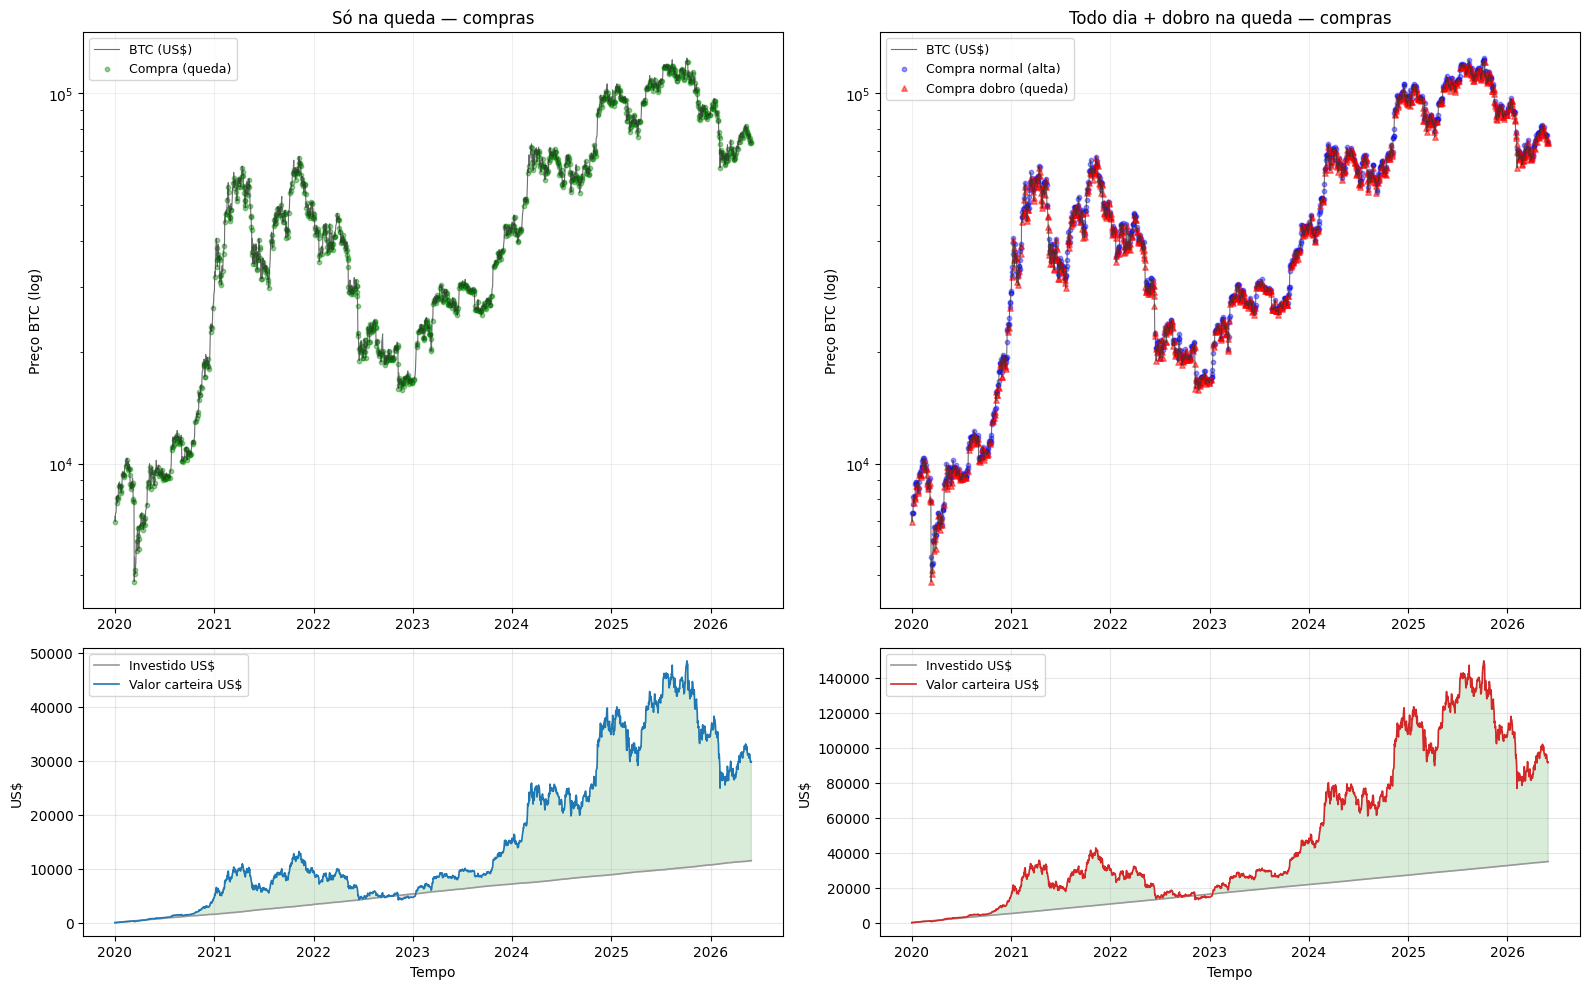

In [26]:
import matplotlib.pyplot as plt

fig, ((ax1, ax1b), (ax2, ax2b)) = plt.subplots(2, 2, figsize=(16, 10),
                                                 gridspec_kw={"height_ratios": [2, 1]})

# Painel 1: Preço com compras (só na queda)
ax1.plot(sim.index, sim["preco"], lw=0.8, color="#333", label="BTC (US$)", alpha=0.7)
compras = sim[sim["comprou"]]
ax1.scatter(compras.index, compras["preco"], s=10, color="green",
            alpha=0.4, label="Compra (queda)")
ax1.set_yscale("log")
ax1.set_ylabel("Preço BTC (log)")
ax1.set_title("Só na queda — compras")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(alpha=0.2)

# Painel 2: Preço com compras (todo dia + dobro na queda)
ax1b.plot(sim_dobro_queda.index, sim_dobro_queda["preco"], lw=0.8, color="#333", label="BTC (US$)", alpha=0.7)
compras_dobro = sim_dobro_queda[sim_dobro_queda["comprou"]]
compras_dobro_normal = compras_dobro[~compras_dobro["queda"]]
compras_dobro_doubled = compras_dobro[compras_dobro["queda"]]
ax1b.scatter(compras_dobro_normal.index, compras_dobro_normal["preco"], s=10, color="blue",
            alpha=0.4, label="Compra normal (alta)")
ax1b.scatter(compras_dobro_doubled.index, compras_dobro_doubled["preco"], s=15, color="red",
            alpha=0.5, marker="^", label="Compra dobro (queda)")
ax1b.set_yscale("log")
ax1b.set_ylabel("Preço BTC (log)")
ax1b.set_title("Todo dia + dobro na queda — compras")
ax1b.legend(loc="upper left", fontsize=9)
ax1b.grid(alpha=0.2)

# Painel 3: Carteiras (só na queda)
ax2.plot(sim.index, sim["investido"], color="#999", lw=1.2, label="Investido US$")
ax2.plot(sim.index, sim["valor"], color="#1f77b4", lw=1.2, label="Valor carteira US$")
ax2.fill_between(sim.index, sim["investido"], sim["valor"],
                 where=sim["valor"] >= sim["investido"],
                 color="green", alpha=0.15)
ax2.fill_between(sim.index, sim["investido"], sim["valor"],
                 where=sim["valor"] < sim["investido"],
                 color="red", alpha=0.15)
ax2.set_ylabel("US$")
ax2.set_xlabel("Tempo")
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(alpha=0.3)

# Painel 4: Carteiras (todo dia + dobro na queda)
ax2b.plot(sim_dobro_queda.index, sim_dobro_queda["investido"], color="#999", lw=1.2, label="Investido US$")
ax2b.plot(sim_dobro_queda.index, sim_dobro_queda["valor"], color="#d62728", lw=1.2, label="Valor carteira US$")
ax2b.fill_between(sim_dobro_queda.index, sim_dobro_queda["investido"], sim_dobro_queda["valor"],
                 where=sim_dobro_queda["valor"] >= sim_dobro_queda["investido"],
                 color="green", alpha=0.15)
ax2b.fill_between(sim_dobro_queda.index, sim_dobro_queda["investido"], sim_dobro_queda["valor"],
                 where=sim_dobro_queda["valor"] < sim_dobro_queda["investido"],
                 color="red", alpha=0.15)
ax2b.set_ylabel("US$")
ax2b.set_xlabel("Tempo")
ax2b.legend(loc="upper left", fontsize=9)
ax2b.grid(alpha=0.3)

plt.tight_layout()

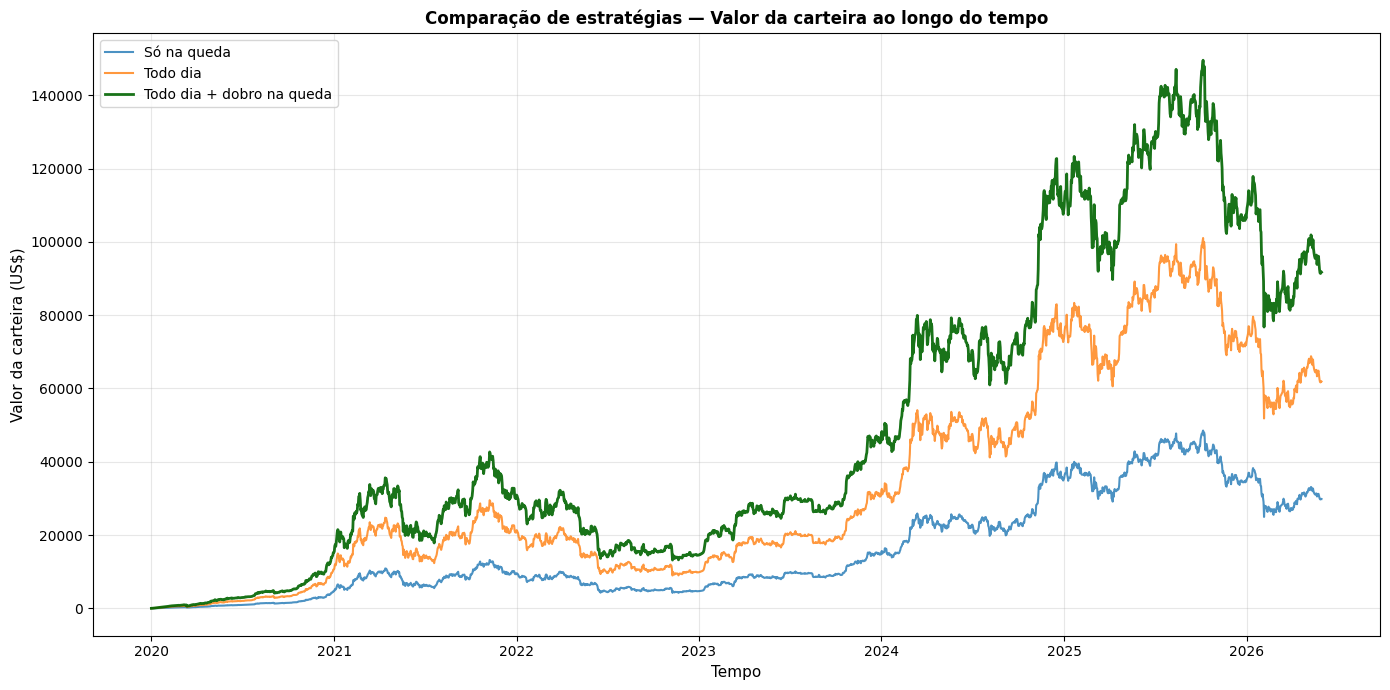

In [27]:

# Comparação visual das carteiras

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(sim.index, sim["valor"], lw=1.5, label="Só na queda", alpha=0.8)
ax.plot(sim_todo_dia.index, sim_todo_dia["valor"], lw=1.5, label="Todo dia", alpha=0.8)
ax.plot(sim_dobro_queda.index, sim_dobro_queda["valor"], lw=2.0, label="Todo dia + dobro na queda", 
        color="darkgreen", alpha=0.9)

ax.set_ylabel("Valor da carteira (US$)", fontsize=11)
ax.set_xlabel("Tempo", fontsize=11)
ax.set_title("Comparação de estratégias — Valor da carteira ao longo do tempo", fontsize=12, fontweight="bold")
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()

---
## Como ler

- **Preço médio pago** — quanto, em média, você pagou por BTC. "Comprar na queda" tende a abaixar esse número vs comprar todo dia, mas a diferença costuma ser pequena.
- **ROI %** — lucro sobre o total investido. Como o aporte é o mesmo (US$ 50), o que muda entre as duas estratégias é *quantos* dias você comprou e a *que preço*.
- **Valor × Investido (gráfico de baixo)** — área verde = carteira acima do investido (no lucro); vermelha = abaixo (no prejuízo). Mostra como o DCA atravessa os ciclos.

**Ressalvas honestas:**
1. Aporte tratado como **US$ 50** (R$ 50 nominal). Em reais de verdade o resultado muda com o câmbio USD/BRL do período.
2. **Sem custos** (fees/spread). Muitas compras pequenas pagam taxa proporcionalmente maior na vida real.
3. DCA é sobre *constância*, não sobre *acertar o fundo*. O backtest mostra se a ideia não é absurda — não garante o futuro.